# Session 10 — The Training Loop

Runs the assignment lab top-to-bottom: tensor shapes, hand gradient check, accumulation bug plot,
grad-norm vs loss, MFU, hand bits, and the 12-row FP / MBS / OAS tables. Writes artifacts under `reports/`.

**Local:** open from `Assign_0010/` so `src` imports resolve, then run all cells.

**Colab:** zip the project (include `src/`, `tests/`, `notebooks/`, `requirements.txt`, `reports/`; omit `.venv/`),
upload, run the Colab setup cell, then remaining cells. Use `requirements.txt` only (Colab already has Jupyter).

Details and formulas: root [`README.md`](../README.md). Summary after a run: [`reports/Assgn010_Summary.md`](../reports/Assgn010_Summary.md).

## Colab setup (skip on local Jupyter)

1. Zip `Assign_0010` with at least: `src/`, `tests/`, `notebooks/`, `requirements.txt` (omit `.venv/`).
2. Upload zip to Colab.
3. Run the next cell (installs `requirements.txt` only).

In [1]:
# === COLAB ONLY — skip this cell when running locally ===
import os
import subprocess
import sys
import zipfile
from pathlib import Path

IN_COLAB = False
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    pass

REQUIRED_REL = [
    "src/pipeline/training_loop_lab.py",
    "requirements.txt",
]


def _find_project_root() -> Path:
    candidates = [Path("/content/Assign_0010"), Path("/content")]
    content = Path("/content")
    if content.is_dir():
        for p in sorted(content.iterdir()):
            if p.is_dir() and p.name not in {".config", "sample_data"}:
                candidates.append(p)
    for c in candidates:
        if (c / "src" / "pipeline" / "training_loop_lab.py").is_file():
            return c
    for c in candidates:
        if (c / "src").is_dir():
            return c
    return Path("/content/Assign_0010")


if IN_COLAB:
    ZIP_NAME = "Assign_0010.zip"
    zip_path = Path("/content") / ZIP_NAME
    if zip_path.is_file():
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall("/content")
    target = _find_project_root()
    os.chdir(target)
    if str(target) not in sys.path:
        sys.path.insert(0, str(target))
    missing = [r for r in REQUIRED_REL if not (target / r).is_file()]
    if missing:
        raise SystemExit(
            "Colab project tree incomplete under "
            + str(target)
            + ". Missing:\n  - "
            + "\n  - ".join(missing)
            + "\nRe-zip Assign_0010, re-upload, Runtime > Restart."
        )
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"]
    )
    print("Colab cwd=", Path.cwd())
    print("ROOT ok.")
else:
    print("Not Colab — skip unzip/pip; use local .venv")


Not Colab — skip unzip/pip; use local .venv


In [2]:
import os
import sys
from pathlib import Path

cwd = Path.cwd()
ROOT = cwd if (cwd / "src").is_dir() else cwd.parent
if not (ROOT / "src" / "pipeline" / "training_loop_lab.py").is_file():
    for candidate in [cwd, cwd.parent, *cwd.parents]:
        if (candidate / "src" / "pipeline" / "training_loop_lab.py").is_file():
            ROOT = candidate
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
assert (ROOT / "src").is_dir(), f"src/ missing under {ROOT}"
print("ROOT=", ROOT)
print("cwd=", Path.cwd())


ROOT= D:\A1_School_ai_25\ERA_V5\Assign_0010
cwd= D:\A1_School_ai_25\ERA_V5\Assign_0010


In [3]:
from src.pipeline.training_loop_lab import run_all

results = run_all(ROOT / "reports")

print("--- Task results ---")
for key in (
    "task1_shapes",
    "task2_gradient",
    "task3_accumulation",
    "task4_grad_norm",
    "task5_mfu",
    "task6_precision",
    "task6_fp_tables",
):
    block = results.get(key, {})
    status = block.get("ok", block.get("passed", True))
    loc = block.get("path", block.get("png_path", block.get("csv_path", "")))
    print(f"  {key}: {'PASS' if status else 'FAIL'} — {loc}")

tables = results.get("task6_fp_tables") or {}
if tables.get("ascii_table1"):
    print()
    print("--- Table 1: FP formats (0.1 at index 0) ---")
    print(tables["ascii_table1"])
if tables.get("ascii_table2"):
    print()
    print("--- Table 2: MXFP4 + MBS + OAS ---")
    print(tables["ascii_table2"])

print()
print("Summary:", results.get("summary_path"))
print("Manifest:", results.get("manifest_path"))


--- Task results ---
  task1_shapes: PASS — D:\A1_School_ai_25\ERA_V5\Assign_0010\reports\assgn010_tensor_shapes.log
  task2_gradient: PASS — D:\A1_School_ai_25\ERA_V5\Assign_0010\reports\assgn010_gradient_check.txt
  task3_accumulation: PASS — D:\A1_School_ai_25\ERA_V5\Assign_0010\reports\assgn010_accumulation_bug.png
  task4_grad_norm: PASS — D:\A1_School_ai_25\ERA_V5\Assign_0010\reports\assgn010_gradnorm_vs_loss.png
  task5_mfu: PASS — D:\A1_School_ai_25\ERA_V5\Assign_0010\reports\assgn010_mfu_report.md
  task6_precision: PASS — D:\A1_School_ai_25\ERA_V5\Assign_0010\reports\assgn010_precision_bits.md
  task6_fp_tables: PASS — D:\A1_School_ai_25\ERA_V5\Assign_0010\reports\assgn010_fp_format_table.md

--- Table 1: FP formats (0.1 at index 0) ---
+-------------------+------------------------------+-----------------+-------------+-------------------+
| Format Name       | Bit Layout                   | Quantized Value | Abs Error % | Simulation Case   |
+-------------------+------------

D:\A1_School_ai_25\ERA_V5\Assign_0010\reports\assgn010_accumulation_bug.png


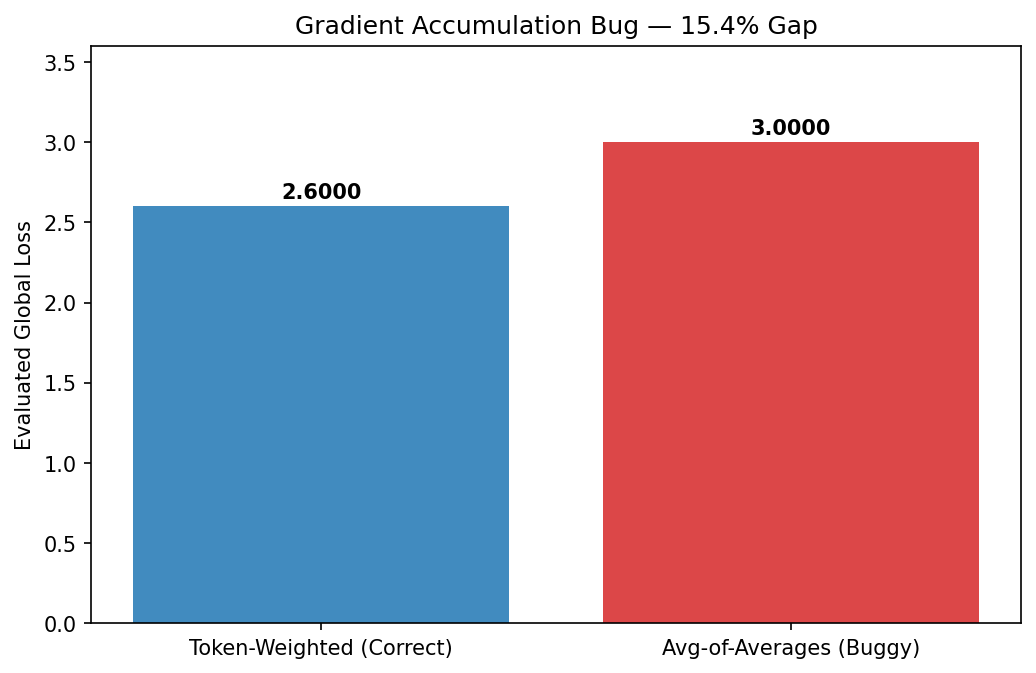

D:\A1_School_ai_25\ERA_V5\Assign_0010\reports\assgn010_gradnorm_vs_loss.png


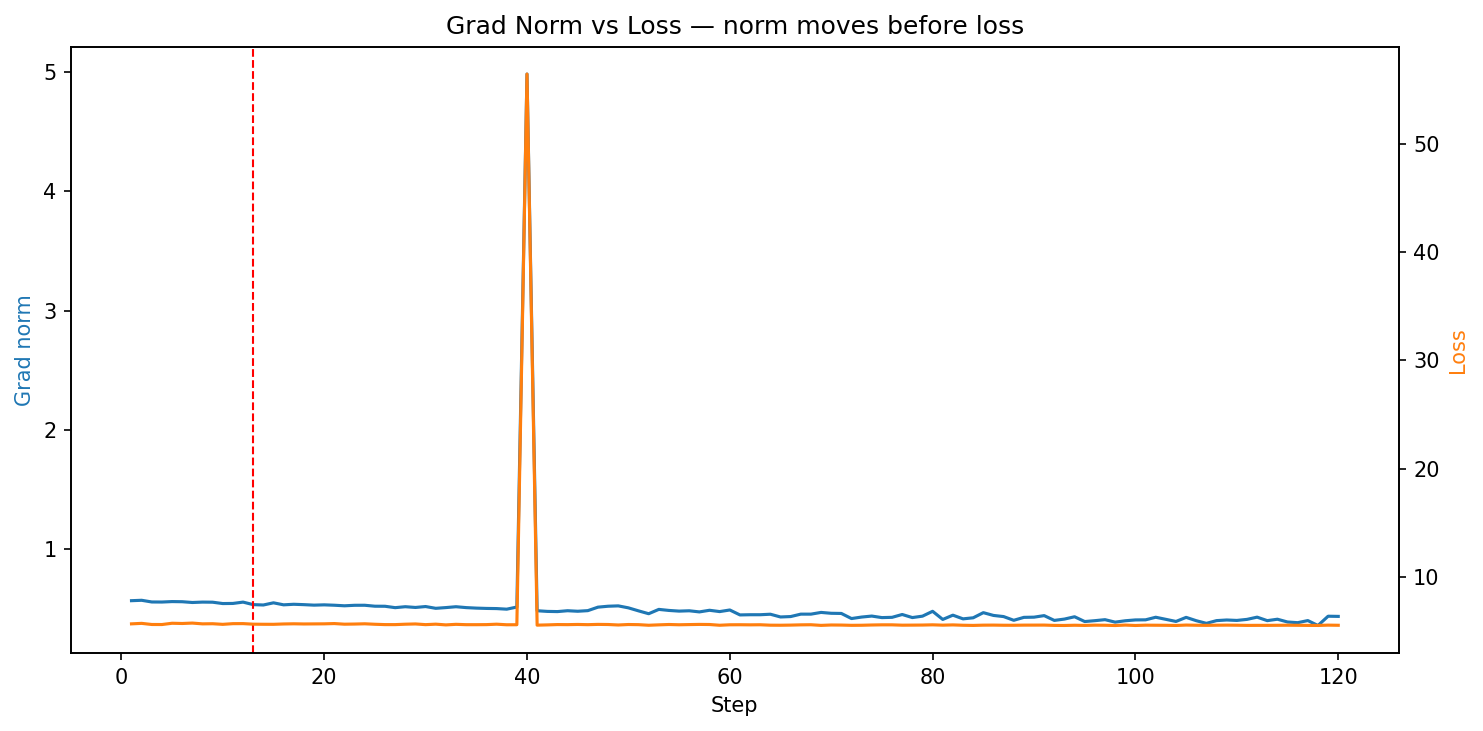

In [4]:
from IPython.display import Image, display

for name in (
    "assgn010_accumulation_bug.png",
    "assgn010_gradnorm_vs_loss.png",
):
    path = ROOT / "reports" / name
    assert path.is_file() and path.stat().st_size > 0, f"missing plot: {path}"
    print(path)
    display(Image(filename=str(path)))


In [5]:
ok = bool(results.get("all_ok"))
print("VERIFICATION GATE:", "PASS" if ok else "FAIL")
if not ok:
    raise RuntimeError(
        "Assignment verification gate failed — see reports/ and task statuses above."
    )


VERIFICATION GATE: PASS
